In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df= pd.read_csv("sales_data_with_discounts.csv" )

In [17]:
df.shape

(450, 13)

In [18]:
df.columns

Index(['Date', 'Day', 'SKU', 'City', 'Volume', 'BU', 'Brand', 'Model',
       'Avg Price', 'Total Sales Value', 'Discount Rate (%)',
       'Discount Amount', 'Net Sales Value'],
      dtype='object')

In [19]:
num =df.select_dtypes( include= [np.number] ).columns.tolist()
print(num)

['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)', 'Discount Amount', 'Net Sales Value']


In [20]:
for c in num:
    print( c )
    val_mean = df[c].mean()
    val_med = df[c].median()
    val_mode = df[c].mode()[0]
    val_std =df[c].std()
    print("Mean:", val_mean)
    print("Median:", val_med)
    print("Mode:", val_mode)
    print("Std:", val_std)

Volume
Mean: 5.066666666666666
Median: 4.0
Mode: 3
Std: 4.231602391213926
Avg Price
Mean: 10453.433333333332
Median: 1450.0
Mode: 400
Std: 18079.90483993645
Total Sales Value
Mean: 33812.83555555555
Median: 5700.0
Mode: 24300
Std: 50535.07417255328
Discount Rate (%)
Mean: 15.155241895330914
Median: 16.57776564929597
Mode: 5.007822189204133
Std: 4.220602153325511
Discount Amount
Mean: 3346.499424342415
Median: 988.9337332382784
Mode: 69.17794228822787
Std: 4509.9029633539985
Net Sales Value
Mean: 30466.336131270138
Median: 4677.788059301853
Mode: 326.97480055470817
Std: 46358.656624066934


### Interpretation of Descriptive Statistics
* **Volume**: Small order sizes (~5 units) with low variability.
* **Price & Sales**: High mean vs low median indicates right-skewed data (a few expensive items).
* **Discounts**: Consistent strategy averaging around 15%.

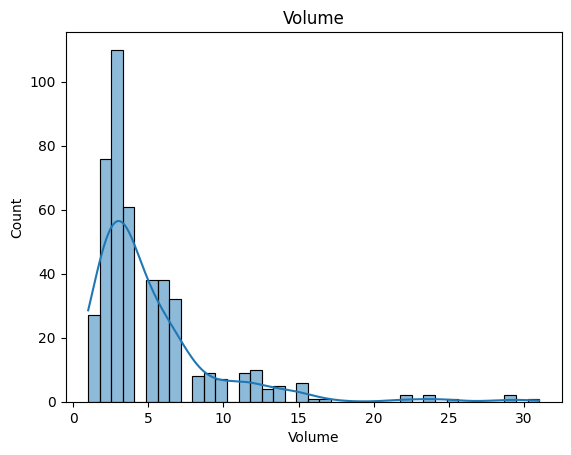

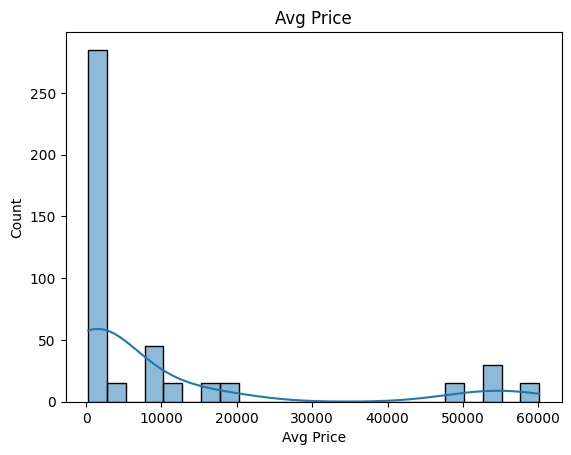

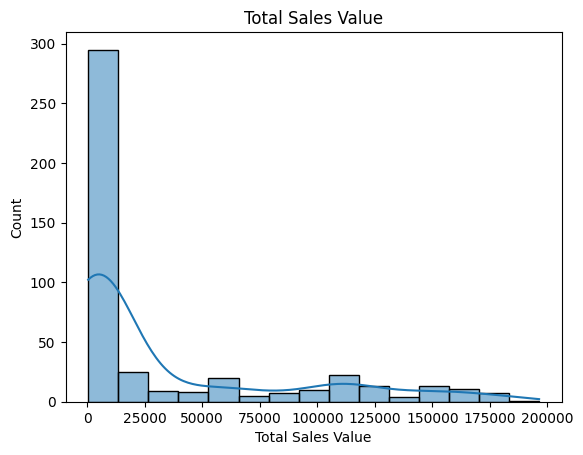

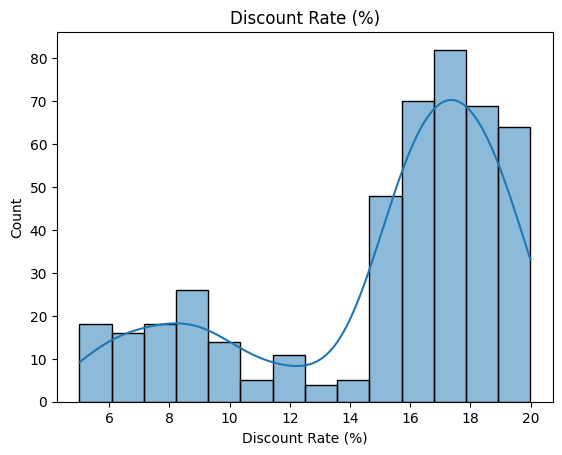

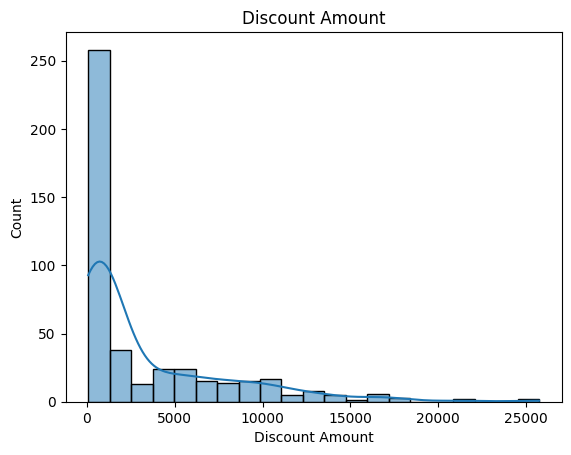

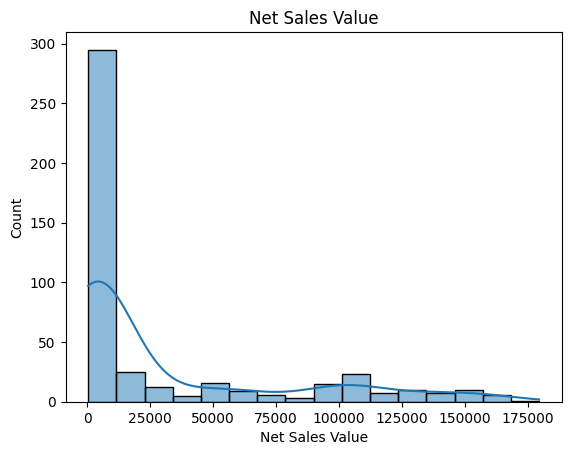

In [21]:
for c in num:
    plt.figure()
    sns.histplot(df[ c ],kde= True)
    plt.title( c)
    plt.show()

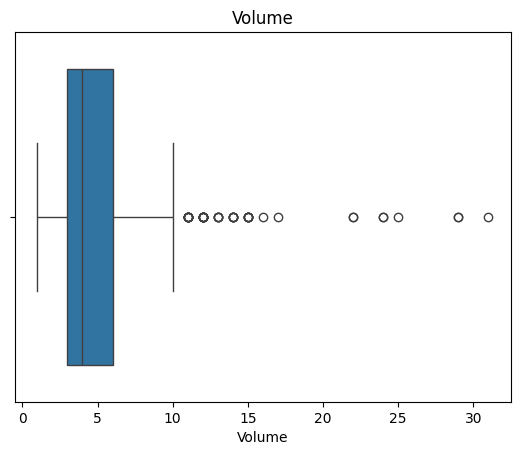

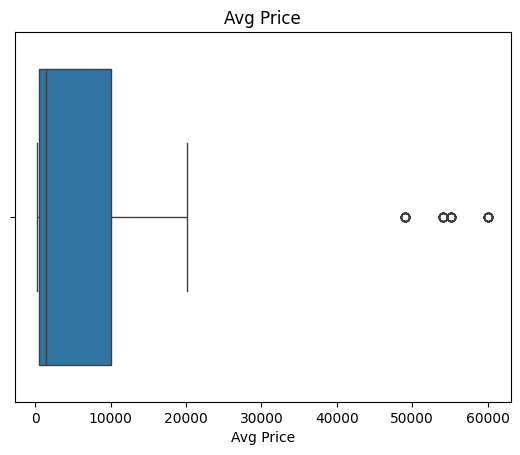

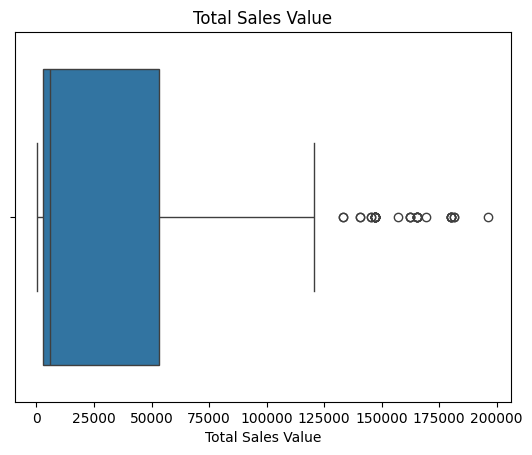

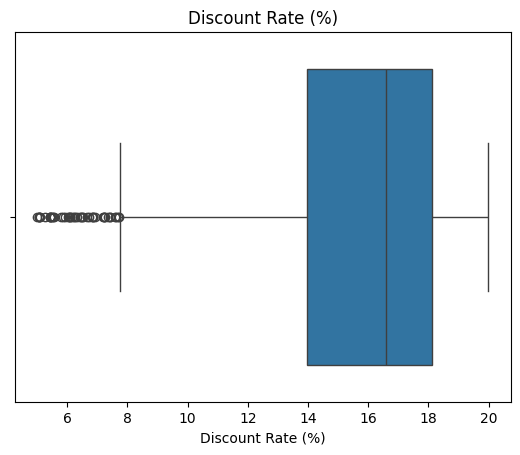

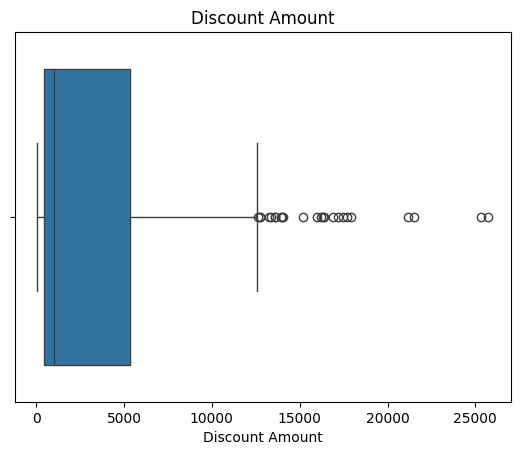

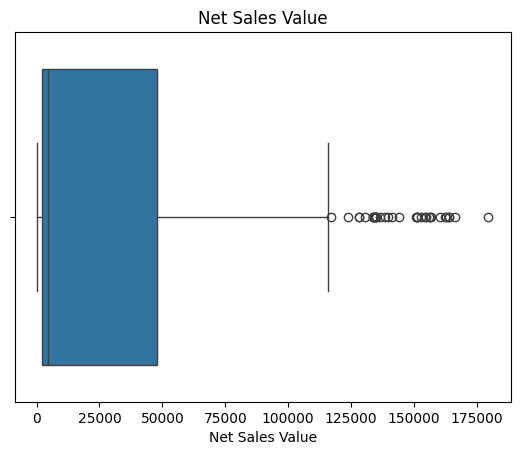

In [22]:
for c in num:
    plt.figure()
    sns.boxplot( x=df[c] )
    plt.title( c )
    plt.show()

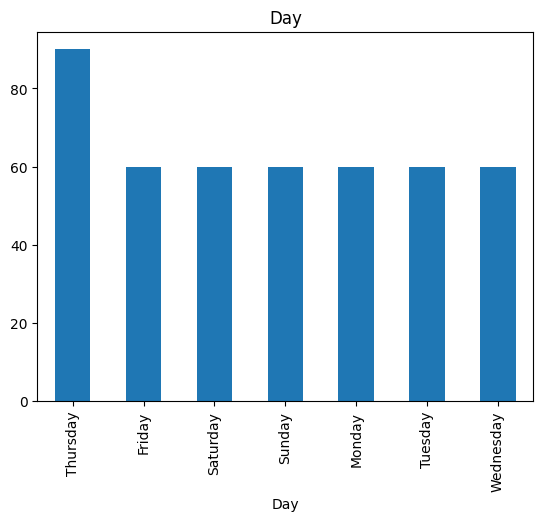

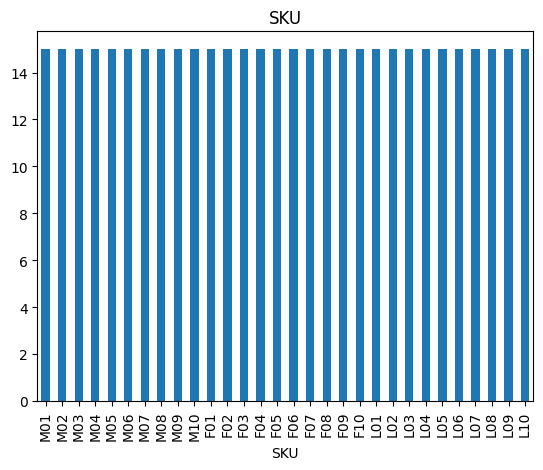

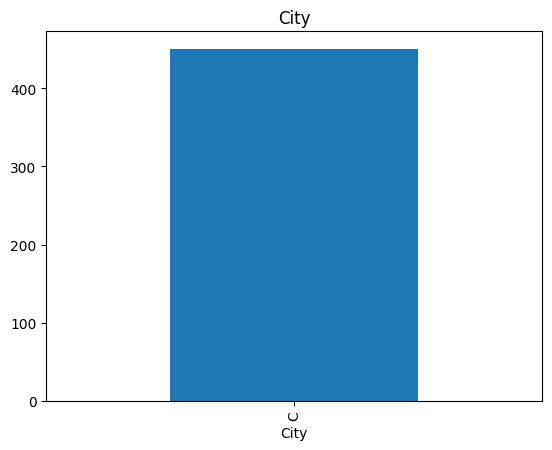

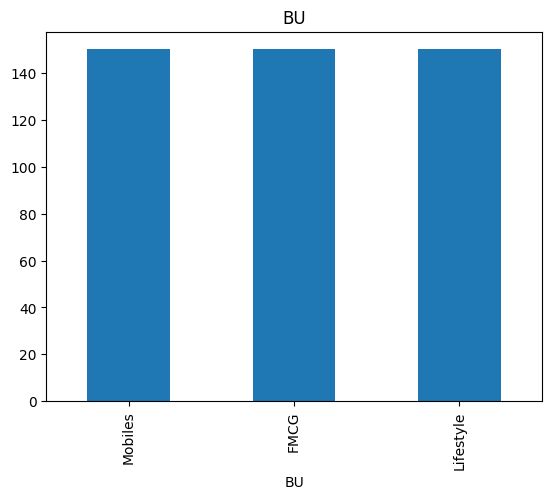

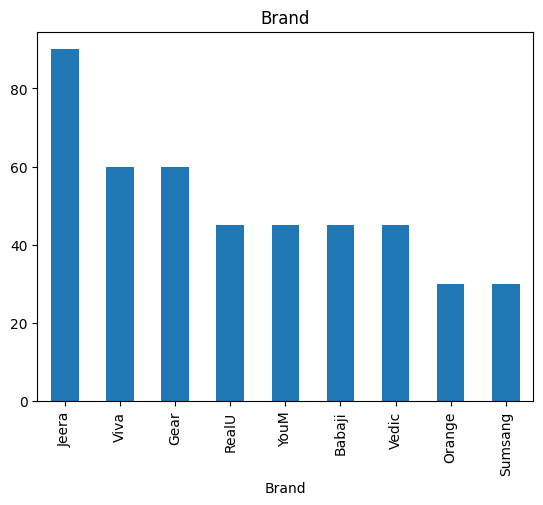

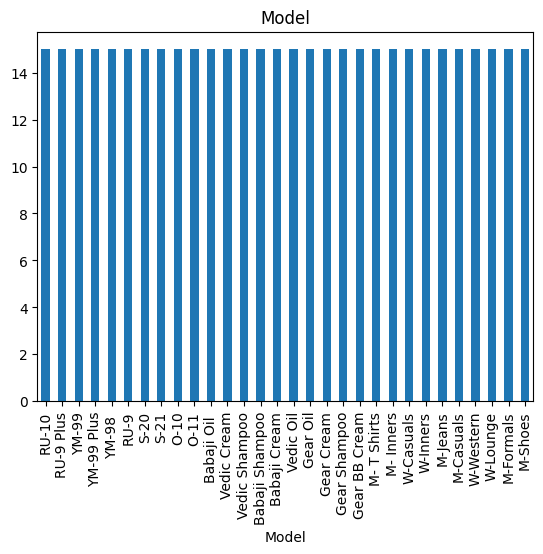

In [23]:
cat = df.select_dtypes(include= ["object"] ).columns.tolist()
for c in cat:
    if c != "Date":
        plt.figure( )
        df[c].value_counts().plot(kind= "bar")
        plt.title(c)
        plt.show()

In [24]:
# preprocessing
df2= df.copy()
for c in num:
    m_val = df[c].mean()
    s_val = df[c].std()
    df2[c + "_z"] = (df[c] - m_val) / s_val

for c in num:
    min_val = df[c].min()
    max_val = df[c].max()
    df2[c + "_mm"] = (df[c] - min_val) / (max_val - min_val)

df2 = pd.get_dummies(df2, columns = ["Day"])
df2 = pd.get_dummies(df2, columns = ["BU"])
df2 = pd.get_dummies(df2, columns = ["City"])
df2.head()

,Date,SKU,Volume,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value,...,Day_Monday,Day_Saturday,Day_Sunday,Day_Thursday,Day_Tuesday,Day_Wednesday,BU_FMCG,BU_Lifestyle,BU_Mobiles,City_C
0,01-04-2021,M01,15,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180,...,False,False,False,True,False,False,False,False,True,True
1,01-04-2021,M02,10,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039,...,False,False,False,True,False,False,False,False,True,True
2,01-04-2021,M03,7,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843,...,False,False,False,True,False,False,False,False,True,True
3,01-04-2021,M04,6,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298,...,False,False,False,True,False,False,False,False,True,True
4,01-04-2021,M05,3,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770,...,False,False,False,True,False,False,False,False,True,True


# Concluding Summary
1. **Skewed Sales**: Revenue is driven by a small number of high-value transactions.
2. **Steady Discounts**: Promotional rates are standardized between 10-20%.
3. **Prepared Data**: Features are now normalized and encoded for machine learning.
4. **Limited Scope**: Analysis is currently specific to 'City C'.